# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [3]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [4]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0], std=0.05)
perturb_td = pyal.restrict_to_interval(
    df_tr,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_1794413/1430965440.py:2: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


In [5]:
perturb_td_shuff.bhv.values[0].shape

(501, 36)

In [ ]:
area_x = 'MOp'
origin_rank = 20
window = (0, 150)
td_potent_null = subspaces.compute_potent_null_td(
    td_=perturb_td_shuff,
    signal_x=f'{area_x}_rates_pca',
    signal_y='bhv',
    origin_rank=origin_rank,
    target_rank=36,
    n_iter=2,
    window=window
)

  drop_trials_sem_crosses_zero: by SEM: 207  |  by value: 423  |  kept: 206/424 (48.6%)
Disturbance — null: 0.1317  potent: 0.3414  lb: 0.0096
Direction     — null: 0.2088  potent: 0.2517  lb: 0.0728  chance: 0.0833


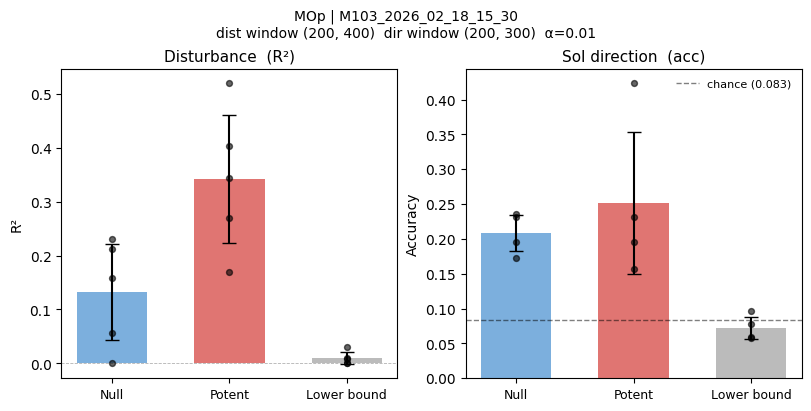

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold

td_potent_null_dropped = dsp.drop_trials_sem_crosses_zero(td_potent_null, std=True)

td_potent_null_ord = (
    td_potent_null_dropped
    .sort_values(by='trial_id')
    .reset_index(drop=True)
)

window_dist = (200, 400)   # mean-pooled for disturbance decoding
window_dir  = (200, 300)   # flattened for direction decoding
alpha = 0.01
shuffle = False

# ── arrays ────────────────────────────────────────────────────────────────────
null_mean   = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_bhv'].values)[:, window_dist[0]:window_dist[1], :].mean(1)
potent_mean = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_bhv'].values)[:, window_dist[0]:window_dist[1], :].mean(1)

null_flat   = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_null_bhv'].values)[:, window_dir[0]:window_dir[1], :]
null_flat   = null_flat.reshape(null_flat.shape[0], -1)
potent_flat = np.stack(td_potent_null_ord[f'{area_x}_rates_pca_potent_bhv'].values)[:, window_dir[0]:window_dir[1], :]
potent_flat = potent_flat.reshape(potent_flat.shape[0], -1)

y_dist = td_potent_null_ord.disturb_sum.values
y_dir  = np.array(td_potent_null_ord.values_Sol_direction.values.tolist())

rng  = np.random.default_rng(42)
perm = rng.permutation(len(y_dist))

# ── disturbance decoding (Ridge, R²) ─────────────────────────────────────────
cv_dist = KFold(5, shuffle=shuffle)
r2s_null   = cross_val_score(Ridge(alpha), null_mean,   y_dist,       scoring=decode.get_custom_scorer(), cv=cv_dist)
r2s_potent = cross_val_score(Ridge(alpha), potent_mean, y_dist,       scoring=decode.get_custom_scorer(), cv=cv_dist)
r2s_lb     = cross_val_score(Ridge(alpha), potent_mean, y_dist[perm], scoring=decode.get_custom_scorer(), cv=cv_dist)

print(f'Disturbance — null: {r2s_null.mean():.4f}  potent: {r2s_potent.mean():.4f}  lb: {r2s_lb.mean():.4f}')

# ── direction decoding (GaussianNB, accuracy) ─────────────────────────────────
perm_dir = rng.permutation(len(y_dir))
cv_dir   = StratifiedKFold(4, shuffle=shuffle)
acc_null   = cross_val_score(GaussianNB(), null_flat,   y_dir,          scoring='accuracy', cv=cv_dir)
acc_potent = cross_val_score(GaussianNB(), potent_flat, y_dir,          scoring='accuracy', cv=cv_dir)
acc_lb     = cross_val_score(GaussianNB(), potent_flat, y_dir[perm_dir], scoring='accuracy', cv=cv_dir)

print(f'Direction     — null: {acc_null.mean():.4f}  potent: {acc_potent.mean():.4f}  lb: {acc_lb.mean():.4f}  chance: {1/12:.4f}')

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

panels = [
    (axes[0], 'Disturbance  (R²)',    [r2s_null, r2s_potent, r2s_lb],  None),
    (axes[1], 'Sol direction  (acc)', [acc_null, acc_potent, acc_lb],   1/12),
]
labels = ['Null', 'Potent', 'Lower bound']
colors_bar = ['#5B9BD5', '#D9534F', '#AAAAAA']

for ax, title, score_list, chance in panels:
    for i, (scores, lbl, col) in enumerate(zip(score_list, labels, colors_bar)):
        ax.bar(i, scores.mean(), color=col, width=0.6, alpha=0.8)
        ax.errorbar(i, scores.mean(), yerr=scores.std(),
                    fmt='none', color='k', capsize=5, linewidth=1.5)
        ax.scatter(np.full(len(scores), i), scores,
                   color='k', s=18, zorder=3, alpha=0.6)
    if chance is not None:
        ax.axhline(chance, color='k', lw=1, ls='--', alpha=0.5, label=f'chance ({chance:.3f})')
        ax.legend(fontsize=8, frameon=False)
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.3)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11)

axes[0].set_ylabel('R²')
axes[1].set_ylabel('Accuracy')
fig.suptitle(f'{area_x} | {SESSIONS[0]}\ndist window {window_dist}  dir window {window_dir}  α={alpha}', fontsize=10)
plt.show()
